In [10]:
import numpy as np
import pandas as pd
import sklearn
from sklearn import datasets
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import adjusted_mutual_info_score
import hdbscan
import foscx

import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import friedmanchisquare
import scikit_posthocs as sp
import os

In [11]:
results_df = pd.read_csv("fosc_synthetic_results.csv")

In [12]:
score_col = "ari_best"
df = results_df.copy()

# combine hierarchy + procedure into a single method name
df["method_name"] = df["method"] + "_" + df["procedure"]

df = df[["dataset", "dataset_id", "method_name", score_col]]

In [37]:

def evaluate_hierarchy(df, score_col="ari_best", out_dir="results"):

    os.makedirs(out_dir, exist_ok=True)

    sns.set_theme(style="whitegrid", context="paper")

    hierarchies = ["Ward", "HDBSCAN*"]

    pivots = {}
    ranks = {}
    nemenyi_results = {}

    # ---------------------------
    # Boxplots (side-by-side)
    # ---------------------------

    fig, axes = plt.subplots(1, 2, figsize=(14,5), sharey=False)

    for i, hierarchy in enumerate(hierarchies):

        sub = df[df.method_name.str.startswith(hierarchy)].copy()

        # Build complete dataset-method matrix
        pivot = sub.pivot_table(
            index=["dataset", "dataset_id"],
            columns="method_name",
            values=score_col
        )

        # Remove datasets with any missing method
        pivot = pivot.dropna()

        # Convert back to long form for seaborn
        sub = (
            pivot
            .reset_index()
            .melt(
                id_vars=["dataset", "dataset_id"],
                var_name="method_name",
                value_name=score_col
            )
        )

        sub["method_clean"] = sub["method_name"].str.replace(
            f"{hierarchy.lower()}_", "", regex=False
        )

        # preserve original method order
        method_order = (
            df[df.method_name.str.startswith(hierarchy)]["method_name"]
            .drop_duplicates()
            .str.replace(f"{hierarchy.lower()}_", "", regex=False)
            .tolist()
        )


        ax = axes[i]

        sns.boxplot(
            data=sub,
            x="method_clean",
            y=score_col,
            order=method_order,
            ax=ax,
            palette="Set2",
            showfliers=False
        )


        if hierarchy.lower() == "ward":
            ax.set_title("(a) Ward-Linkage")
        else:
            ax.set_title("(b) HDBSCAN*")

        ax.set_xlabel("")
        ax.set_ylabel("Adjusted Mutual Information" if i == 0 else "")
        ax.tick_params(axis="x", rotation=40)

    #fig.suptitle("Synthetic Dataset Performance", fontsize=14)
    # Ward: full range
    axes[0].set_ylim(0, 1.01)
    #axes[0].set_yticks(np.arange(0, 1.01, 0.2))

    # HDBSCAN: truncated range
    axes[1].set_ylim(0.7, 1.01)
    #axes[1].set_yticks(np.arange(0.75, 1.01, 0.05))
    plt.tight_layout()

    fig.savefig(os.path.join(out_dir, "boxplots.pdf"), bbox_inches="tight")
    fig.savefig(os.path.join(out_dir, "boxplots.png"), dpi=300)

    plt.show()

    # ---------------------------
    # Process each hierarchy
    # ---------------------------

    for hierarchy in hierarchies:
        if hierarchy == "HDBSCAN*":
            hierarchy2 = "HDBSCAN"
        else:
            hierarchy2 = hierarchy
        print("\n==============================")
        print(f"Evaluating {hierarchy.upper()}")
        print("==============================")

        sub = df[df.method_name.str.startswith(hierarchy)]

        pivot = sub.pivot_table(
            index=["dataset", "dataset_id"],
            columns="method_name",
            values=score_col
        )

        pivot = pivot.dropna()
        
        #pivot = pivot[pivot.var(axis=1) > 0]

        print("Datasets used:", len(pivot))

        pivot_reset = pivot.reset_index(drop=True)

        pivots[hierarchy] = pivot_reset

        # ---------------------------
        # Friedman test
        # ---------------------------

        stat, p = friedmanchisquare(
            *[pivot_reset[col] for col in pivot_reset.columns]
        )

        print("\nFriedman statistic:", stat)
        print("p-value:", p)

        # ---------------------------
        # Nemenyi test
        # ---------------------------

        nemenyi = sp.posthoc_nemenyi_friedman(pivot_reset)

        nemenyi_results[hierarchy] = nemenyi

        # save latex table
        latex_table = nemenyi.to_latex(
            float_format="%.4g",
            caption=f"Nemenyi post-hoc test p-values ({hierarchy})",
            label=f"tab:nemenyi_{hierarchy}"
        )

        with open(os.path.join(out_dir, f"nemenyi_{hierarchy2}.tex"), "w") as f:
            f.write(latex_table)

        print("\nSaved LaTeX table:", f"nemenyi_{hierarchy}.tex")

        # ---------------------------
        # Average ranks
        # ---------------------------

        avg_ranks = pivot_reset.rank(axis=1, ascending=False).mean()

        ranks[hierarchy] = avg_ranks

        rank_table = avg_ranks.sort_values().to_frame("Average Rank")

        rank_latex = rank_table.to_latex(
            float_format="%.3f",
            caption=f"Average ranks ({hierarchy})",
            label=f"tab:ranks_{hierarchy}"
        )

        with open(os.path.join(out_dir, f"ranks_{hierarchy2}.tex"), "w") as f:
            f.write(rank_latex)

        print("Saved LaTeX table:", f"ranks_{hierarchy}.tex")

        # ---------------------------
        # Critical Difference Diagram
        # ---------------------------

        plt.figure(figsize=(10,2))

        sp.critical_difference_diagram(
            avg_ranks,
            nemenyi,
        )

        plt.tight_layout()

        plt.savefig(
            os.path.join(out_dir, f"cd_{hierarchy2}.pdf"),
            bbox_inches="tight"
        )

        plt.savefig(
            os.path.join(out_dir, f"cd_{hierarchy2}.png"),
            dpi=300
        )

        plt.show()

    

    return pivots, nemenyi_results, ranks

C:\Users\simpson\AppData\Local\Temp\1\ipykernel_38960\3980795137.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\simpson\AppData\Local\Temp\1\ipykernel_38960\3980795137.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


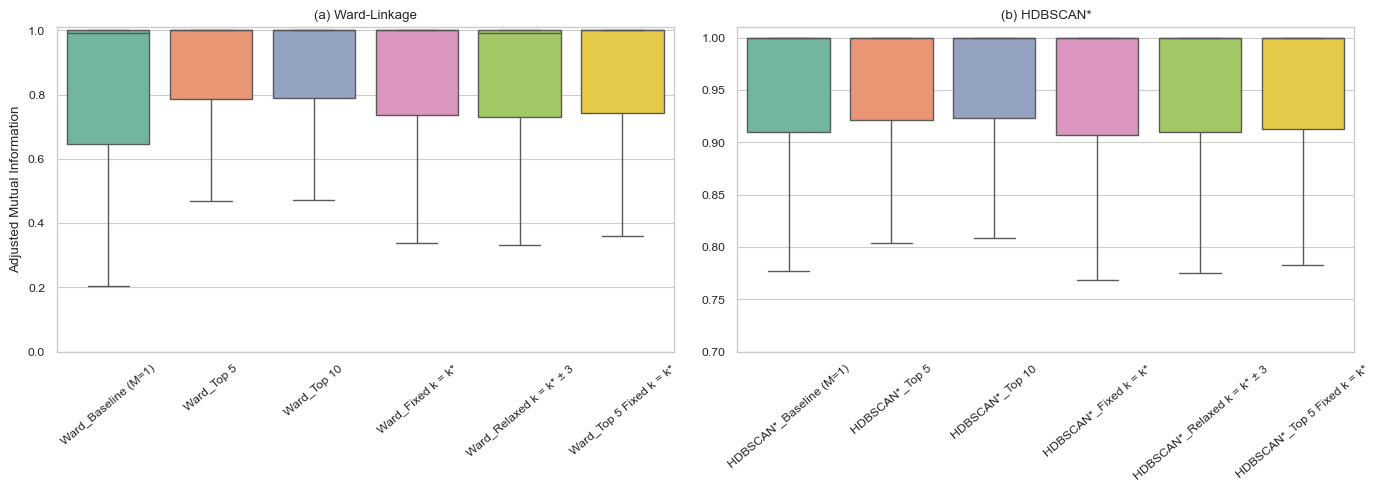


Evaluating WARD
Datasets used: 2100

Friedman statistic: 2718.5833823119924
p-value: 0.0

Saved LaTeX table: nemenyi_Ward.tex
Saved LaTeX table: ranks_Ward.tex


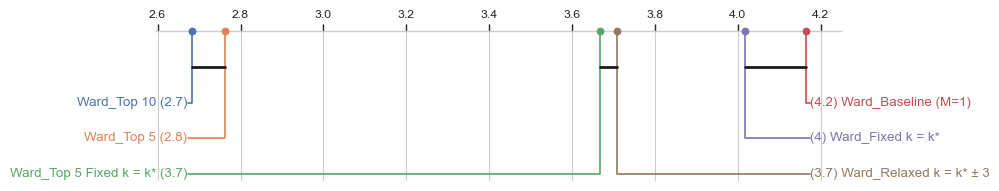


Evaluating HDBSCAN*
Datasets used: 1988

Friedman statistic: 1333.0524427603918
p-value: 4.409675903513297e-286

Saved LaTeX table: nemenyi_HDBSCAN*.tex
Saved LaTeX table: ranks_HDBSCAN*.tex


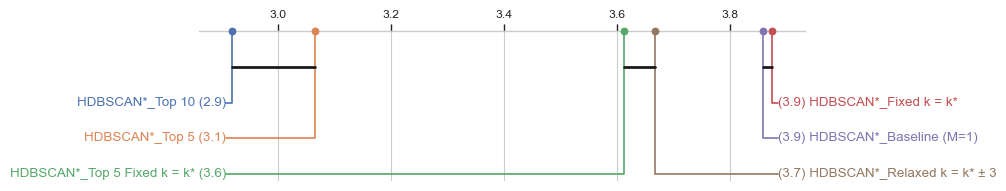

In [38]:
pivots, nemenyi_results, ranks = evaluate_hierarchy(df)